In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import shap

from xgboost import XGBClassifier

import joblib
from utils.utils import feature_engineering

## 1 · Carga de datos y Split


In [2]:
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 60)

DATA_PATH = 'data/raw/novapay_transacciones.csv'
df_raw = pd.read_csv(DATA_PATH)
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (100000, 17)


,id_transaccion,id_usuario,fecha,hora,dias_antiguedad_cuenta,email_verificado,pais_emision,categoria,importe,es_online,pais_pago,tipo_tarjeta,mismo_envio_facturacion,tipo_dispositivo,uso_vpn_proxy,paso_3d_secure,es_fraude
0,322018a1-24ae-4c31-7d85-a873a8e4f69a,756a9a6d-0a72-5b57-2d6b-f721eabc6efa,2025-01-01 00:00:00,0,0,1,GB,Supermercado,58.37,1,GB,Débito,1,Móvil,0,1,0
1,4fcee3c3-4c61-eef8-531b-50dcc3561152,6bfab445-eb98-1ba0-519c-81ac6d53d972,2025-01-01 00:09:00,0,268,1,BR,Supermercado,88.18,1,BR,Crédito,0,Móvil,0,0,0
2,31b0946c-5282-3ca2-4503-f2b16b395875,3bd3290a-b74e-64dd-6473-20f2d130c7e5,2025-01-01 00:12:00,0,641,1,FR,Electrónica,11.29,1,FR,Crédito,1,Tablet,0,0,0
3,7f62d465-740c-7aea-1796-d0bcd44ab299,75957b92-bdc4-1feb-3325-8d75b19f7ae3,2025-01-01 00:13:00,0,0,1,DE,Electrónica,587.66,1,DE,Crédito,1,Móvil,0,1,0
4,346d7ab9-88d3-891c-08b4-de0c83c6bfe9,3e7266c5-4e26-87fd-2079-9e085a6b0964,2025-01-01 00:20:00,0,0,1,ES,Suscripciones,335.41,1,CN,Crédito,0,Móvil,0,0,1


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_transaccion           100000 non-null  str    
 1   id_usuario               100000 non-null  str    
 2   fecha                    100000 non-null  str    
 3   hora                     100000 non-null  int64  
 4   dias_antiguedad_cuenta   100000 non-null  int64  
 5   email_verificado         100000 non-null  int64  
 6   pais_emision             100000 non-null  str    
 7   categoria                100000 non-null  str    
 8   importe                  100000 non-null  float64
 9   es_online                100000 non-null  int64  
 10  pais_pago                100000 non-null  str    
 11  tipo_tarjeta             100000 non-null  str    
 12  mismo_envio_facturacion  100000 non-null  int64  
 13  tipo_dispositivo         100000 non-null  str    
 14  uso_vpn_proxy   

In [4]:
# Numéricas
num_cols = [
    'hora',
    'dias_antiguedad_cuenta',
    'importe',
]

# Categóricas
cat_cols = [
    'pais_emision',
    'pais_pago',
    'categoria',
    'tipo_tarjeta',
    'tipo_dispositivo'
]

## 2 · EDA


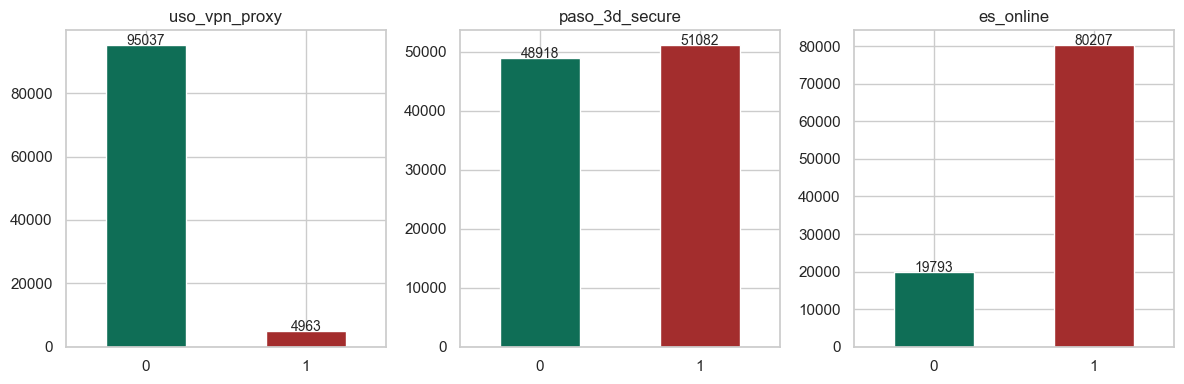

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, ['uso_vpn_proxy', 'paso_3d_secure', 'es_online']):
    df_raw[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#0F6E56', '#A32D2D'])
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 100, 
                f'{int(p.get_height())}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

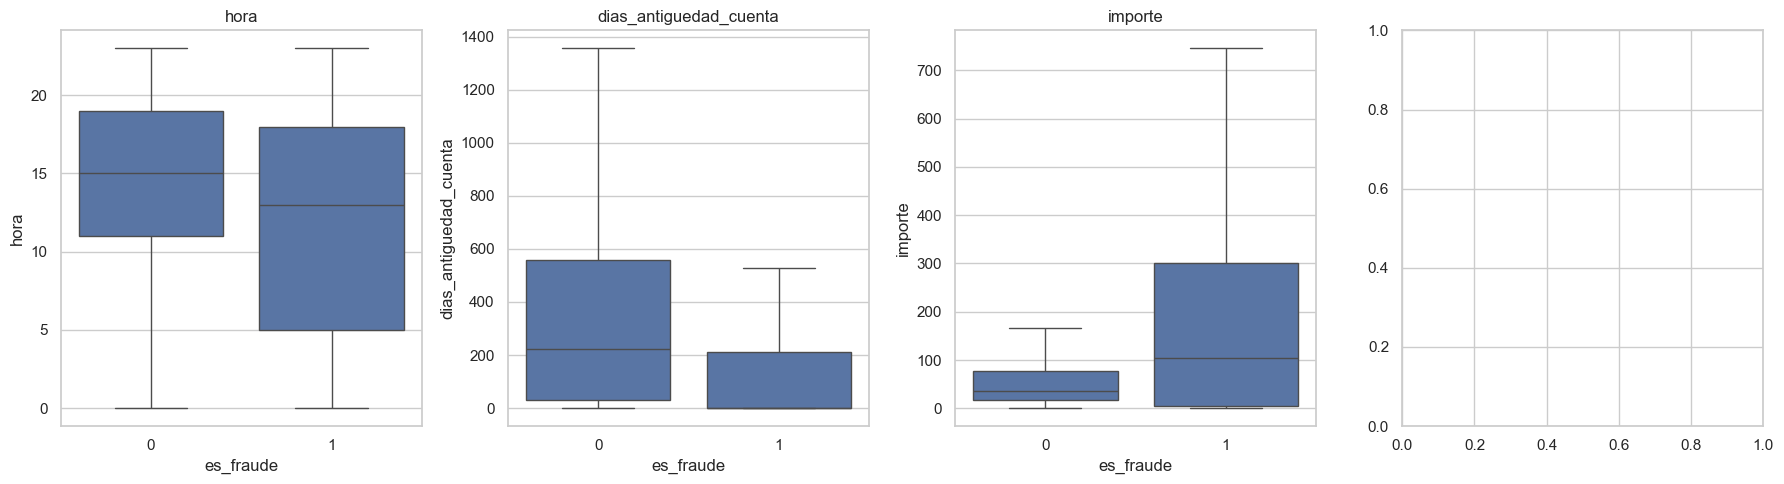

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes.flat, num_cols):
    # boxplot por target
    sns.boxplot(data=df_raw, x='es_fraude', y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [7]:
def fraud_rate_by(col, df=None, top=15):
    if df is None:
        df = df_raw
    out = df.groupby(col, dropna=False)['es_fraude'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    out['mean'] = (out['mean'] * 100).round(2)
    out.columns = ['fraude_%', 'n']
    return out.head(top)

for c in ['tipo_tarjeta', 'tipo_dispositivo', 'pais_emision', 'pais_pago', 'categoria']:
    print(f'\n=== {c} ===')
    print(fraud_rate_by(c))


=== tipo_tarjeta ===
              fraude_%      n
tipo_tarjeta                 
Prepago          49.47   8635
Crédito           9.25  38734
Débito            8.08  52631

=== tipo_dispositivo ===
                  fraude_%      n
tipo_dispositivo                 
Desktop              24.32  25171
Tablet               12.75   5552
Móvil                 9.72  49484
Físico (TPV)          2.36  19793

=== pais_emision ===
              fraude_%      n
pais_emision                 
FR               14.49   7917
GB               13.20   4168
DE               12.92   6850
ES               12.35  54433
IT               11.89   4391
IN               11.67   1071
MX               11.53   2905
CN               11.48   1908
JP               10.64    677
US               10.59   5070
PT               10.55   6466
BR                9.99   1501
RU                6.17   2643

=== pais_pago ===
           fraude_%      n
pais_pago                 
IN            50.73   1782
CN            43.06   2729

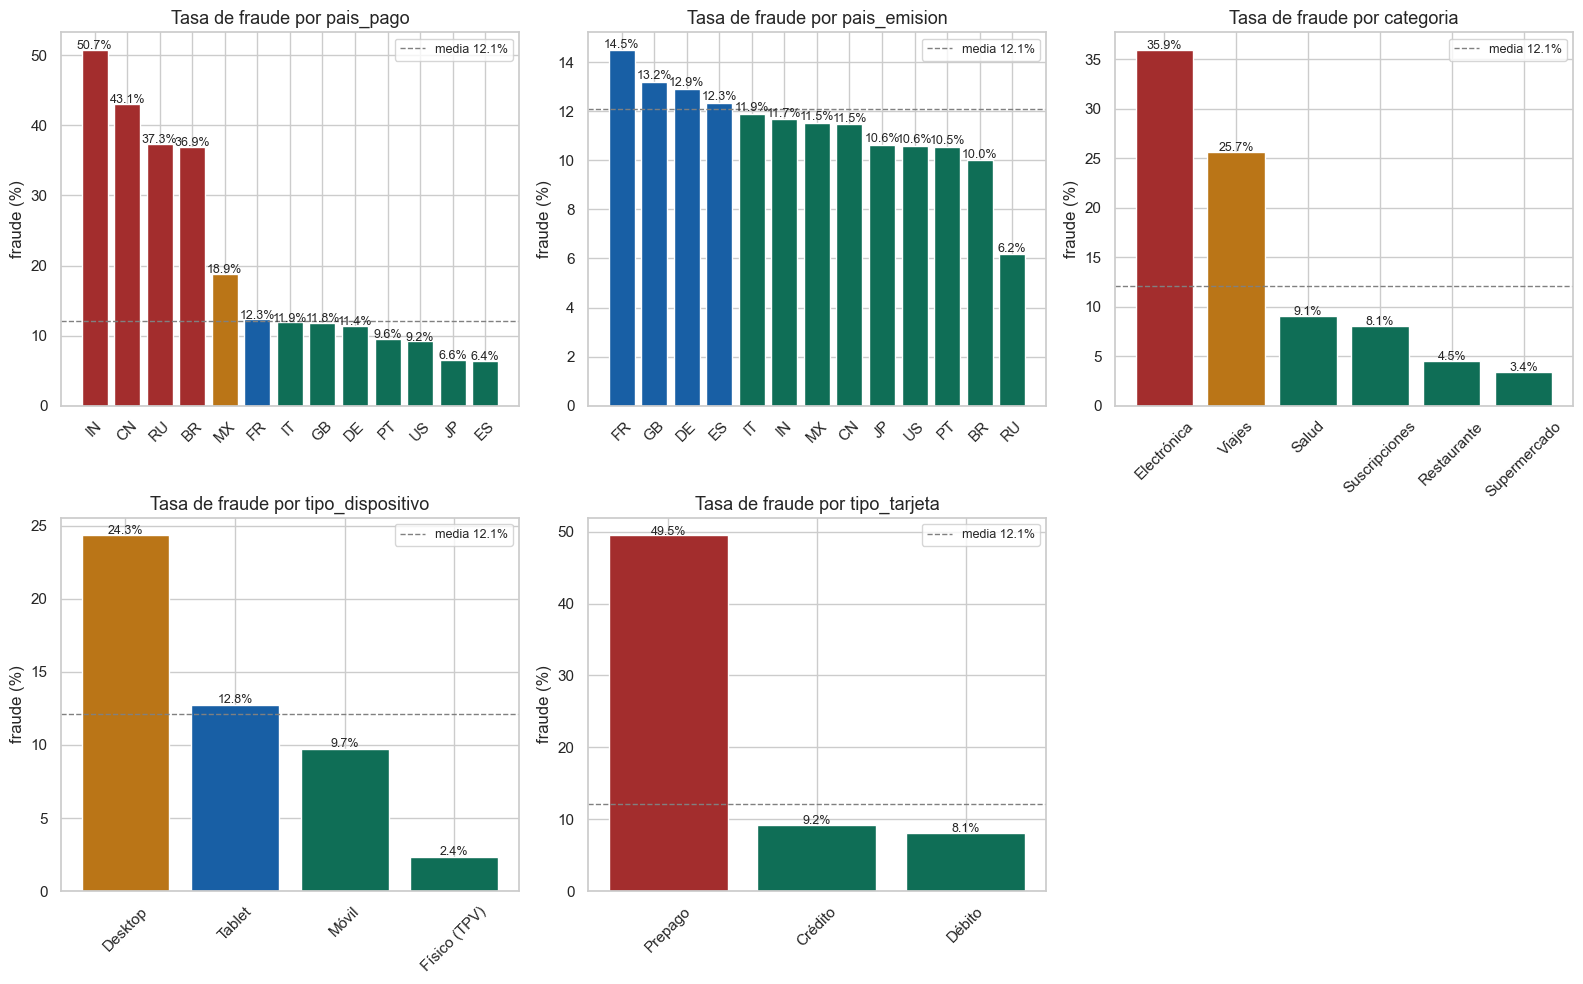

In [8]:
def plot_fraud_rate(col, df, top=15, ax=None):
    data = df.groupby(col)['es_fraude'].mean().sort_values(ascending=False).head(top) * 100
    
    # Umbrales relativos a la tasa base del dataset
    base = df['es_fraude'].mean() * 100
    colors = [
        '#A32D2D' if v >= base * 2.5 else   # >2.5x la media → rojo
        '#BA7517' if v >= base * 1.5 else   # >1.5x la media → naranja  
        '#185FA5' if v >= base else          # >media → azul
        '#0F6E56'                            # <media → verde
        for v in data.values
    ]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    
    ax.bar(data.index, data.values, color=colors)
    ax.axhline(y=base, color='gray', linestyle='--', linewidth=1, label=f'media {base:.1f}%')
    ax.set_title(f'Tasa de fraude por {col}', fontsize=13)
    ax.set_ylabel('fraude (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)
    
    return ax

cols = ['pais_pago', 'pais_emision', 'categoria', 'tipo_dispositivo', 'tipo_tarjeta']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    plot_fraud_rate(col, df_raw, ax=axes[i])

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('data/reports/eda_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### 3 insights clave:

- pais_pago RU/CN/IN: tasa 8-10% vs ES 0.9% -> feature pago_pais_alto_riesgo muy potente
- Electrónica: 4.62% vs media 2% -> feature categoria_riesgo
- Tipo de tarjeta: diferencia mínima -> feature de bajo valor predictivo

Nota: No eliminaremos tipo_tarjeta, aunque no aporta mucho al modelo, lo veremos en SHAP.

### Columnas que deben ser elimiandas.

- id_transaccion
- id_usuario

In [9]:
df_raw = df_raw.drop(columns=['id_transaccion', 'id_usuario'])

### Dividimos en Train y Test para comenzar el tratamiento del Train

In [10]:
TARGET = 'es_fraude'

X = df_raw.drop(columns=[TARGET])
y = df_raw[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' fraude=', y_train.mean().round(4))
print('Test :', X_test.shape, ' fraude=', y_test.mean().round(4))

Train: (80000, 14)  fraude= 0.1211
Test : (20000, 14)  fraude= 0.1211


## 3 · Feature Engineering

In [11]:
# === Feature Engineering manual (DEPRECADO) ===
# Todo el feature engineering ahora lo hace exclusivamente utils.py::feature_engineering
# dentro del pipeline (paso 'fe' del Pipeline de sklearn).
# Las siguientes líneas se conservan comentadas como referencia histórica.
#
# df_train = X_train.copy()
#
# # Fecha
# df_train['fecha'] = pd.to_datetime(df_train['fecha'])
# df_train['dia_semana'] = df_train['fecha'].dt.dayofweek      # 0=lunes, 6=domingo
# df_train['es_fin_de_semana'] = (df_train['dia_semana'] >= 5).astype(int)
# df_train['mes'] = df_train['fecha'].dt.month
# df_train = df_train.drop(columns=['fecha'])
#
# # País
# df_train['pais_alto_riesgo'] = df_train['pais_pago'].isin(['RU','CN','IN']).astype(int)
# df_train['pais_distinto'] = (df_train['pais_emision'] != df_train['pais_pago']).astype(int)
#
# # Hora
# df_train['hora_madrugada'] = df_train['hora'].between(0, 5).astype(int)  # 0 a 5 am devuelve 1
#
# # Categoría
# df_train['categoria_alto_riesgo'] = (df_train['categoria'] == 'Electrónica').astype(int)
#
# # Combinaciones
# df_train['online_sin_3ds'] = ((df_train['es_online'] == 1) & (df_train['paso_3d_secure'] == 0)).astype(int)

## 4 · Pipeline: OHE + Scaling + scale_pos_weight (sin SMOTE)

**Por qué usamos `scale_pos_weight` en vez de SMOTE:**

Es la forma recomendada en la industria (2025-2026) para gradient boosting en fraude. No genera datos sintéticos, es más rápido, más reproducible y suele dar mejor calibración de probabilidades. El valor **7.26** sale de `n_negativos / n_positivos` en el train (ver explicación detallada + conteos exactos en la celda de código siguiente).

In [12]:
num_cols = ['hora', 'dias_antiguedad_cuenta', 'importe']
cat_cols = [
    'pais_emision',
    'pais_pago', 
    'categoria',
    'tipo_tarjeta',
    'tipo_dispositivo'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

In [13]:
# ============================================================
# LISTAS ALTO RIESGO (solo train) — umbrales relativos al baseline
# ============================================================
base_rate = y_train.mean()
print(f'Baseline fraude (train): {base_rate:.4f}\n')

# --- Países: tasa de fraude > 1.5× el baseline ---
_tasas_pais = pd.concat([X_train['pais_pago'], y_train], axis=1) \
                .groupby('pais_pago')['es_fraude'].mean() \
                .sort_values(ascending=False)
paises_alto_riesgo = tuple(_tasas_pais[_tasas_pais > 1.5 * base_rate].index.tolist())

# --- Categorías: tasa de fraude > 1.3× el baseline ---
_tasas_cat = pd.concat([X_train['categoria'], y_train], axis=1) \
               .groupby('categoria')['es_fraude'].mean() \
               .sort_values(ascending=False)
categorias_alto_riesgo = tuple(_tasas_cat[_tasas_cat > 1.3 * base_rate].index.tolist())

# --- Visibilidad ---
print('Tasa fraude por país (train):')
print(_tasas_pais.round(4).to_string(), '\n')
print('Tasa fraude por categoría (train):')
print(_tasas_cat.round(4).to_string(), '\n')

print(f'Países alto riesgo  ({len(paises_alto_riesgo)}/{X_train["pais_pago"].nunique()}): '
      f'{paises_alto_riesgo}')
print(f'Categorías alto riesgo ({len(categorias_alto_riesgo)}/{X_train["categoria"].nunique()}): '
      f'{categorias_alto_riesgo}')

# --- Sanity checks ---
assert 0 < len(paises_alto_riesgo) < X_train['pais_pago'].nunique(), (
    f'Multiplicador de país mal calibrado: '
    f'{len(paises_alto_riesgo)}/{X_train["pais_pago"].nunique()} marcados'
)
assert 0 < len(categorias_alto_riesgo) < X_train['categoria'].nunique(), (
    f'Multiplicador de categoría mal calibrado: '
    f'{len(categorias_alto_riesgo)}/{X_train["categoria"].nunique()} marcados'
)

# ============================================================
# scale_pos_weight  (reemplaza a SMOTE 
# EXPLICACIÓN COMPLETA
# ============================================================
# ¿De dónde sale el número?
#   scale_pos_weight = n_negativos / n_positivos   (en el TRAIN)
#
# En este dataset:
#   - Legítimas (0): ~70.312
#   - Fraudes (1):   ~9.688
#   - Ratio = 70.312 / 9.688 ≈ 7.26
#
# ¿Qué significa y qué hace realmente este parámetro?
#
# XGBoost es un algoritmo de boosting que en cada iteración calcula
# gradientes y hessianos para minimizar la pérdida.
#
# Cuando pones scale_pos_weight=7.26:
#   - Multiplicas por 7.26 el gradiente (y hessiano) de TODAS las
#     observaciones de la clase positiva (fraude).
#   - Efecto práctico: los errores en fraude "duelen" ~7.26 veces más
#     durante el entrenamiento.
#
# Es la forma NATIVA y recomendada en la industria de dar más peso
# a la clase minoritaria **sin generar datos sintéticos**.
#
# Ventajas frente a SMOTE:
#   - No aumentas el tamaño del dataset (más rápido + menos RAM)
#   - No introduces ruido artificial en las fronteras de decisión
#   - Las probabilidades de salida suelen estar mejor calibradas
#   - Es reproducible y fácil de explicar a negocio
#
# Cómo elegir el valor:
#   1. Valor clásico (baseline): n_neg / n_pos, lo que usamos aquí
#   2. Si quieres MÁS RECALL (atrapar más fraude, aunque suban alertas):
#      súbelo (8-12 o incluso más)
#   3. Si quieres MÁS PRECISION (menos falsos positivos):
#      bájalo (4-6)
#   4. Lo ideal a futuro: tunearlo con validación + métrica de negocio
#      (ej. minimizar coste total con una matriz de costes)
#
# En este proyecto usamos el valor clásico (7.26) porque:
#   - Es simple y transparente
#   - Da muy buen recall (94%) manteniendo PR-AUC excelente
#   - Sigue las recomendaciones actuales de la industria para
#     gradient boosting en detección de fraude
#
# ============================================================

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"\nDistribución en TRAIN:")
print(f"  Legítimas (0): {n_neg:,}")
print(f"  Fraudes   (1): {n_pos:,}")
print(f"  Fraud rate : {n_pos / (n_neg + n_pos):.4f}")
print(f"\n>>> scale_pos_weight = {scale_pos_weight:.2f}  (n_neg / n_pos)")

# ============================================================
# PIPELINE (sklearn Pipeline, sin SMOTE)
# ============================================================
pipeline = Pipeline(steps=[
    ('fe', FunctionTransformer(
        feature_engineering,
        validate=False,
        kw_args={
            'paises_alto_riesgo': paises_alto_riesgo,
            'categorias_alto_riesgo': categorias_alto_riesgo,
        },
    )),
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        n_jobs=-1,
    ))
])

Baseline fraude (train): 0.1211

Tasa fraude por país (train):
pais_pago
IN    0.5067
CN    0.4315
RU    0.3755
BR    0.3657
MX    0.1845
FR    0.1256
IT    0.1182
GB    0.1174
DE    0.1141
PT    0.0971
US    0.0945
ES    0.0629
JP    0.0614 

Tasa fraude por categoría (train):
categoria
Electrónica      0.3603
Viajes           0.2557
Salud            0.0935
Suscripciones    0.0803
Restaurante      0.0460
Supermercado     0.0342 

Países alto riesgo  (5/13): ('IN', 'CN', 'RU', 'BR', 'MX')
Categorías alto riesgo (2/6): ('Electrónica', 'Viajes')

Distribución en TRAIN:
  Legítimas (0): 70,313
  Fraudes   (1): 9,687
  Fraud rate : 0.1211

>>> scale_pos_weight = 7.26  (n_neg / n_pos)


## 5 · Entrenamiento de XGBoost

In [14]:
# --- XGBoost ---
xgb_params = {
    'clf__n_estimators': [300, 500, 800, 1200],
    'clf__max_depth':    [4, 5, 6, 7, 8],
    'clf__learning_rate':[0.02, 0.05, 0.08, 0.1],
    'clf__subsample':    [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree':[0.6, 0.8, 1.0],
    'clf__min_child_weight':[1, 3, 5, 10],
    'clf__gamma':       [0, 0.1, 0.5, 1.0],
    'clf__reg_lambda':  [0.5, 1.0, 2.0, 5.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rs_xgb = RandomizedSearchCV(
    pipeline,
    xgb_params,
    n_iter=25,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)
rs_xgb.fit(X_train, y_train)

print('Mejor PR-AUC XGB:', rs_xgb.best_score_.round(4))
print('Mejor combo:', rs_xgb.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Mejor PR-AUC XGB: 0.9602
Mejor combo: {'clf__subsample': 0.9, 'clf__reg_lambda': 0.5, 'clf__n_estimators': 500, 'clf__min_child_weight': 10, 'clf__max_depth': 4, 'clf__learning_rate': 0.05, 'clf__gamma': 1.0, 'clf__colsample_bytree': 0.6}


In [15]:
y_pred_proba = rs_xgb.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.50).astype(int)

print(classification_report(y_test, y_pred))
print('PR-AUC:', round(average_precision_score(y_test, y_pred_proba), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, y_pred_proba), 4))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     17578
           1       0.77      0.94      0.85      2422

    accuracy                           0.96     20000
   macro avg       0.88      0.95      0.91     20000
weighted avg       0.96      0.96      0.96     20000

PR-AUC: 0.9596
ROC-AUC: 0.9911


In [16]:
proba_xgb = rs_xgb.best_estimator_.predict_proba(X_test)[:, 1]

In [17]:
# Tabla de operación: cómo cambian precision/recall según threshold
candidatos_thr = np.linspace(0.05, 0.95, 19)
rows = []
for t in candidatos_thr:
    p = (proba_xgb >= t).astype(int)
    rows.append({
        'threshold': round(t, 2),
        'precision_1': precision_score(y_test, p, zero_division=0),
        'recall_1': recall_score(y_test, p, zero_division=0),
        'f1_1': f1_score(y_test, p, zero_division=0),
        'positivos_predichos': p.sum(),
    })
df_thr = pd.DataFrame(rows).round(4)
display(df_thr)

# ============================================================
# ANÁLISIS DE COSTE (prioridad del negocio: MAXIMIZAR RECALL)
# ============================================================
# El negocio quiere atrapar el máximo fraude posible.
# Por eso ponemos un coste mucho más alto a los fraudes que se escapan.

COSTE_FRAUDE_PERDIDO = 150   # € por cada fraude no detectado
COSTE_FALSA_ALARMA   = 25    # € por cliente legítimo bloqueado (aceptamos más fricción)

df_coste = df_thr.copy()
df_coste['fraudes_perdidos']  = (2422 - df_coste['recall_1'] * 2422).round(0).astype(int)
df_coste['falsos_positivos']  = (df_coste['positivos_predichos'] - df_coste['recall_1'] * 2422).round(0).astype(int)
df_coste['coste_total'] = (df_coste['fraudes_perdidos'] * COSTE_FRAUDE_PERDIDO + 
                           df_coste['falsos_positivos'] * COSTE_FALSA_ALARMA)

print('\nCoste esperado según threshold (prioridad: máximo recall)')
print(df_coste[['threshold', 'recall_1', 'precision_1', 'fraudes_perdidos', 'falsos_positivos', 'coste_total']].to_string(index=False))

mejor = df_coste.loc[df_coste['coste_total'].idxmin()]
print(f'\nMejor threshold según coste del negocio: {mejor.threshold:.2f}  (recall = {mejor.recall_1:.1%})')

,threshold,precision_1,recall_1,f1_1,positivos_predichos
0,0.05,0.3705,0.9950,0.5399,6505
1,0.10,0.4635,0.9901,0.6314,5174
2,0.15,0.5327,0.9827,0.6909,4468
3,0.20,0.5825,0.9777,0.7301,4065
4,0.25,0.6231,0.9715,0.7593,3776
5,0.30,0.6595,0.9653,0.7836,3545
6,0.35,0.6864,0.9616,0.8010,3393
7,0.40,0.7155,0.9554,0.8182,3234
8,0.45,0.7419,0.9492,0.8328,3099
9,0.50,0.7677,0.9401,0.8452,2966



Coste esperado según threshold (prioridad: máximo recall)
 threshold  recall_1  precision_1  fraudes_perdidos  falsos_positivos  coste_total
      0.05    0.9950       0.3705                12              4095       104175
      0.10    0.9901       0.4635                24              2776        73000
      0.15    0.9827       0.5327                42              2088        58500
      0.20    0.9777       0.5825                54              1697        50525
      0.25    0.9715       0.6231                69              1423        45925
      0.30    0.9653       0.6595                84              1207        42775
      0.35    0.9616       0.6864                93              1064        40550
      0.40    0.9554       0.7155               108               920        39200
      0.45    0.9492       0.7419               123               800        38450
      0.50    0.9401       0.7677               145               689        38975
      0.55    0.9327       0

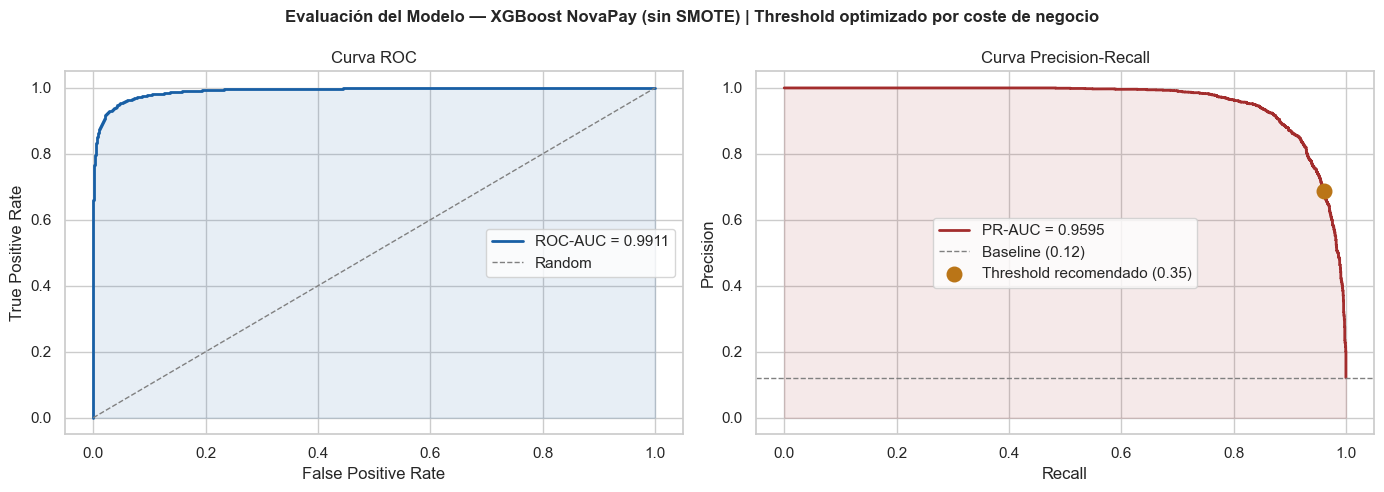

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, proba_xgb)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#185FA5', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0].plot([0,1], [0,1], color='gray', linestyle='--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#185FA5')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend()

# --- PR Curve ---
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_test, proba_xgb)
pr_auc = auc(recall_curve, precision_curve)
base_rate_test = y_test.mean()

axes[1].plot(recall_curve, precision_curve, color='#A32D2D', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=base_rate_test, color='gray', linestyle='--', lw=1, label=f'Baseline ({base_rate_test:.2f})')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color='#A32D2D')

# Marcar threshold recomendado por el negocio (prioridad = máximo recall)
idx = np.argmin(np.abs(thresholds_curve - 0.35))
axes[1].scatter(recall_curve[idx], precision_curve[idx], 
                color='#BA7517', s=110, zorder=5, label='Threshold recomendado (0.35)')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.suptitle('Evaluación del Modelo — XGBoost NovaPay (sin SMOTE) | Threshold optimizado por coste de negocio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('data/reports/curvas_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluación del Modelo y Selección de Threshold

### Métricas globales (threshold = 0.50)

| Métrica | Clase 0 (Legítima) | Clase 1 (Fraude) |
|---|---|---|
| Precision | 0.99 | **0.77** |
| Recall    | 0.96 | **0.94** |
| F1-Score  | 0.98 | **0.85** |

**PR-AUC: 0.9596 · ROC-AUC: 0.9911** (modelo con `scale_pos_weight`)

Soporte: 17.578 legítimas / 2.422 fraudes en test.

---

### El threshold NO es 0.50 (es una decisión de negocio)

El modelo solo da **probabilidades**. El threshold es el corte que decides tú.

**Prioridad del negocio (NovaPay):** **Maximizar Recall**, atrapar el máximo fraude posible, aunque eso signifique más alertas que revisar.

Por eso usar 0.50 es una mala idea por defecto. Es arbitrario y no refleja el coste real del negocio.

### Matriz de coste simple (adaptada a la prioridad del negocio)

| Error del modelo          | Coste aproximado | Por qué |
|---------------------------|------------------|---------|
| Fraude que se escapa (FN) | **150 €**        | Chargeback + pérdida de cliente + riesgo regulatorio |
| Falsa alarma (FP)         | **25 €**         | Fricción del cliente (aceptamos más porque priorizamos seguridad) |

Con esta matriz, el threshold óptimo **baja** (queremos más recall).

Mira el análisis de coste que aparece justo después de la tabla de thresholds. Según el coste del negocio, el mejor punto de operación está alrededor de **0.35** (recall ~96%).

> Regla práctica: cuando el negocio dice "maximizar recall", el threshold óptimo casi siempre está entre 0.25 y 0.40, no en 0.50.  
> Este análisis anteriormente descrito es muy académico de mi parte, en producción según negocio se usa threshold = 0.30

In [19]:
os.makedirs('models', exist_ok=True)

# Pipeline de inferencia: fe + preprocessor + clf
# Estructura IDÉNTICA al pickle de producción
export_pipeline = Pipeline([
    ('fe',           rs_xgb.best_estimator_.named_steps['fe']),
    ('preprocessor', rs_xgb.best_estimator_.named_steps['preprocessor']),
    ('clf',          rs_xgb.best_estimator_.named_steps['clf']),
])

joblib.dump(export_pipeline, 'models/modelo_fraude_v1.pkl')
print('Modelo guardado en models/modelo_fraude_v1.pkl')

Modelo guardado en models/modelo_fraude_v1.pkl


## 6 · Feature Importance y Explicabilidad (SHAP)

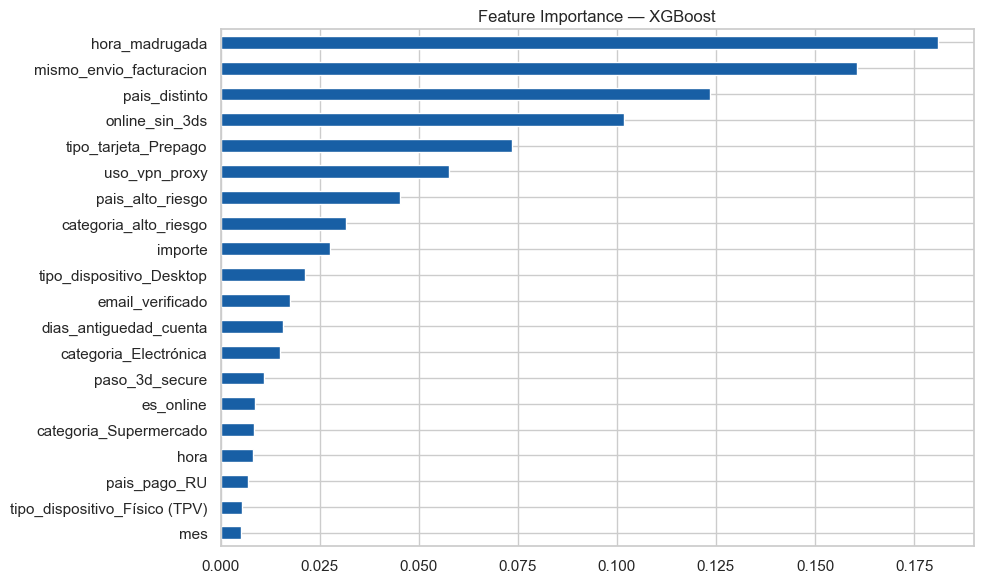

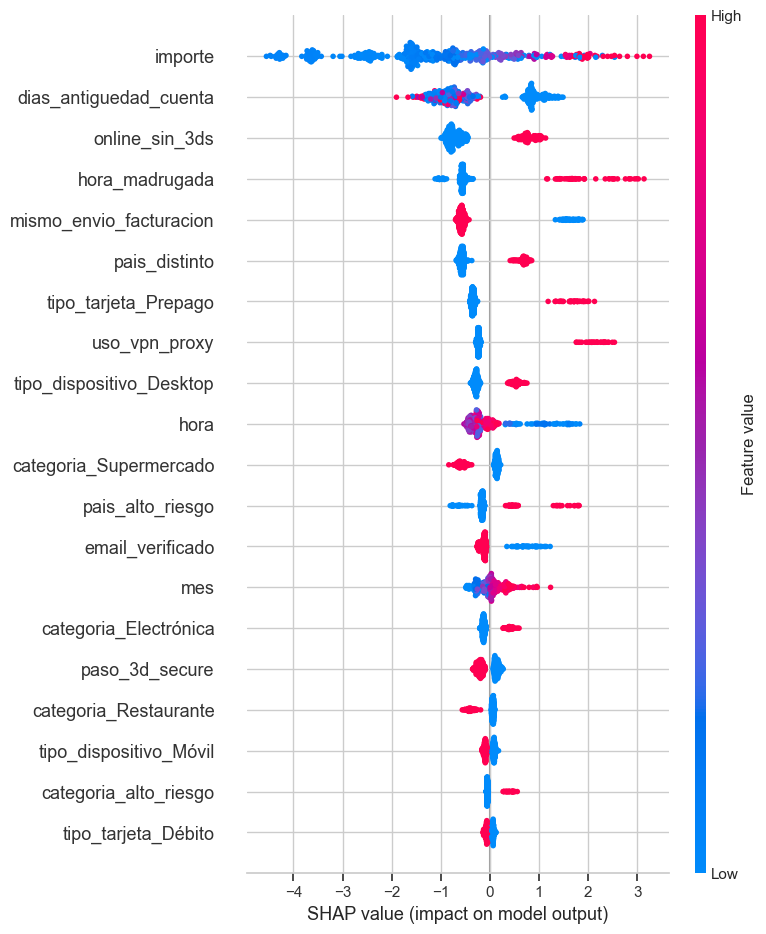

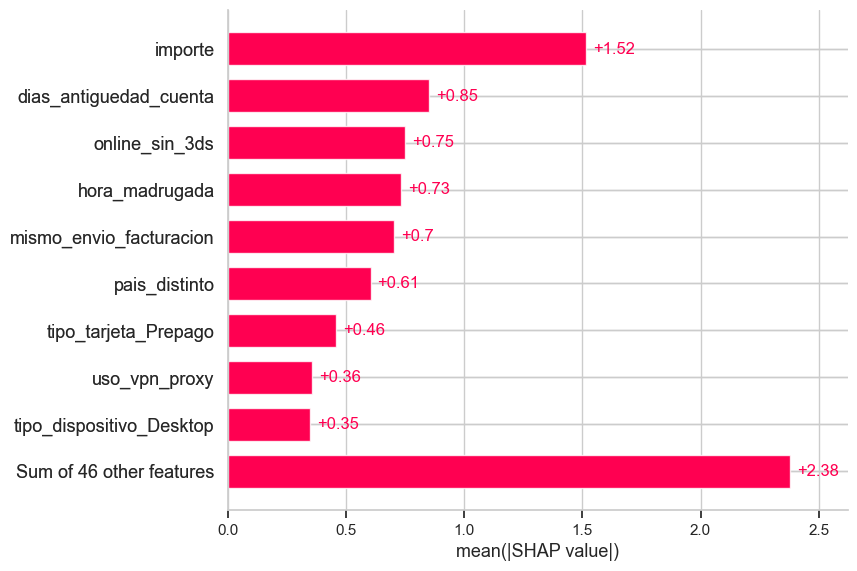

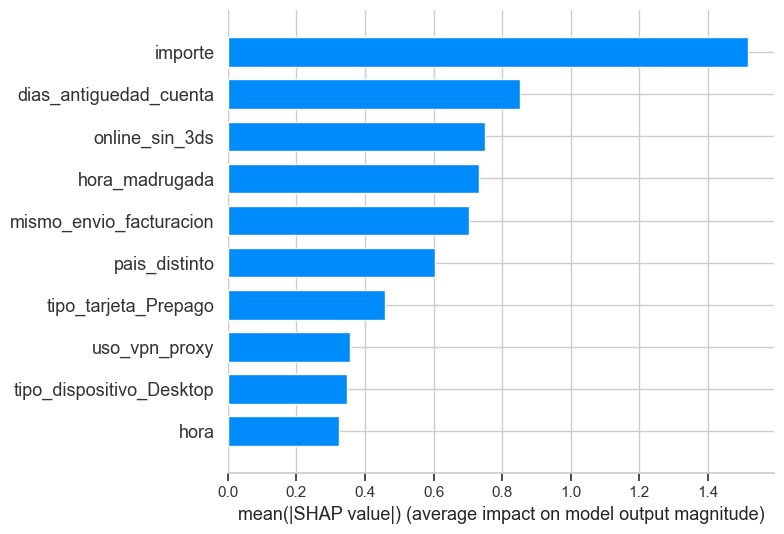

In [20]:
# Extraer modelo
best_model = rs_xgb.best_estimator_
xgb_model = best_model['clf']

# Transformar X_test paso a paso
X_test_fe = feature_engineering(
    X_test,
    paises_alto_riesgo=paises_alto_riesgo,
    categorias_alto_riesgo=categorias_alto_riesgo
)
X_test_transformed = best_model['preprocessor'].transform(X_test_fe)

# Nombres de features tras OHE
ohe_features = best_model['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = num_cols + ohe_features + [
    'email_verificado','es_online','mismo_envio_facturacion',
    'uso_vpn_proxy','paso_3d_secure','dia_semana','es_fin_de_semana',
    'mes','pais_alto_riesgo','hora_madrugada','categoria_alto_riesgo',
    'pais_distinto','online_sin_3ds'
]

# Feature Importance nativa XGBoost
xgb_model = best_model['clf']
importances = pd.Series(xgb_model.feature_importances_, index=all_features)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#185FA5')
ax.set_title('Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('data/reports/feature_importance.png', dpi=150)
plt.show()

# SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed[:500])
shap.summary_plot(shap_values, X_test_transformed[:500], 
                  feature_names=all_features, show=True)

shap.plots.bar(shap.Explanation(
    values=shap_values,
    feature_names=all_features
))
shap.summary_plot(
    shap_values, 
    X_test_transformed[:500],
    feature_names=all_features,
    max_display=10,  # solo top 10
    plot_type='bar'  # barras en vez de puntos
)

In [21]:
import joblib
import pandas as pd
import numpy as np
import shap
import os
import warnings
from utils.utils import feature_engineering

warnings.filterwarnings('ignore')
os.system('clear')

# 1. Cargar
pipeline  = joblib.load('models/modelo_fraude_v1.pkl')
THRESHOLD = 0.50

# 2. Explainer
explainer = shap.TreeExplainer(pipeline['clf'])

# 3. Transacción raw
transaccion = {
    'id_transaccion':          '00000000-0000-0000-0000-000000000001',
    'id_usuario':              '11111111-1111-1111-1111-111111111111',
    'fecha':                   '2026-01-12 14:30:00',
    'dias_antiguedad_cuenta':  1,
    'email_verificado':        1,
    'pais_emision':            'ES',
    'categoria':               'Electrónica',
    'importe':                 1.02,
    'es_online':               1,
    'pais_pago':               'FR',
    'tipo_tarjeta':            'Crédito',
    'mismo_envio_facturacion': 1,
    'tipo_dispositivo':        'Móvil',
    'uso_vpn_proxy':           0,
    'paso_3d_secure':          1,
}

# 4. Predicción
df        = pd.DataFrame([transaccion])
proba     = pipeline.predict_proba(df)[:, 1][0]
es_fraude = proba >= THRESHOLD

# 5. SHAP
df_fe         = pipeline['fe'].transform(df)
X_transformed = pipeline['preprocessor'].transform(df_fe)
shap_values   = explainer.shap_values(X_transformed)[0]

cat_cols     = ['pais_emision', 'pais_pago', 'categoria', 'tipo_tarjeta', 'tipo_dispositivo']
num_cols     = ['hora', 'dias_antiguedad_cuenta', 'importe']
ohe_features = pipeline['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
passthrough  = [c for c in df_fe.columns if c not in num_cols + cat_cols]
all_features = num_cols + ohe_features + passthrough

indices = np.argsort(np.abs(shap_values))[::-1][:5]
top5    = [{'feature': all_features[i], 'impacto': round(float(shap_values[i]), 3)} for i in indices]

# 6. Output
print(f'Probabilidad legítima: {1 - proba:.4f}')
print(f'Probabilidad fraude:   {proba:.4f}')
print(f'Threshold:             {THRESHOLD}')
print(f'Decisión:              {"FRAUDE" if es_fraude else "LEGÍTIMA"}')
print(f'\nTop 5 razones:')
for i, f in enumerate(top5, 1):
    signo = '+' if f['impacto'] > 0 else ''
    print(f"  {i}. {f['feature']:<35} {signo}{f['impacto']:.3f}")

Probabilidad legítima: 0.1124
Probabilidad fraude:   0.8876
Threshold:             0.5
Decisión:              FRAUDE

Top 5 razones:
  1. importe                             +2.505
  2. pais_distinto                       +1.508
  3. dias_antiguedad_cuenta              +0.733
  4. categoria_alto_riesgo               +0.698
  5. online_sin_3ds                      -0.609


In [22]:
pipeline = joblib.load('models/modelo_fraude_v1.pkl')
print(type(pipeline))
print(pipeline)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('fe',
                 FunctionTransformer(func=<function feature_engineering at 0x13ea8f100>,
                                     kw_args={'categorias_alto_riesgo': ('Electrónica',
                                                                         'Viajes'),
                                              'paises_alto_riesgo': ('IN', 'CN',
                                                                     'RU', 'BR',
                                                                     'MX')})),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['hora',
                                                   'dias_antiguedad_cuenta',
                                                   'importe']),
                                                 ('cat',
              